# 02. LLM Benchmark Analysis

Analysis of benchmark results from running quantitative finance interview
questions against multiple LLMs via OpenRouter.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

from settings import config

DATA_DIR = config("DATA_DIR")
OUTPUT_DIR = config("OUTPUT_DIR")
RESULTS_DIR = DATA_DIR / "benchmark_results"
RESULTS_CSV = RESULTS_DIR / "benchmark_results.csv"

## Load Results

In [2]:
df = pd.read_csv(RESULTS_CSV)
df["is_correct"] = df["is_correct"].astype(bool)
print(
    f"Loaded {len(df)} results across {df['model'].nunique()} models "
    f"and {df['question_id'].nunique()} questions"
)
df.head()

Loaded 581 results across 7 models and 91 questions


,question_id,model,question_type,title,source_book,chapter,difficulty,raw_response,extracted_answer,reference_answer,grader_verdict,grader_explanation,is_correct,latency_ms,prompt_tokens,completion_tokens,total_tokens,error,timestamp
0,text_only_q010,openai/gpt-4o,text_only,Calendar cubes,green_book,Ch 2,NaN,"To solve this problem, we need to determine ho...","Die 1: 0, 1, 2, 3, 4, 5; Die 2: 0, 1, 2, 6, 7,...","Dice 1: 0,1,2,3,4,5; Dice 2: 0,1,2,6,7,8 (use ...",YES,The candidate's answer is mathematically equiv...,True,17961.313209,287,671,958,NaN,2026-02-26T12:44:49.746427+00:00
1,text_only_q008,openai/gpt-4o,text_only,Horse race,green_book,Ch 2,NaN,"To solve this problem, we need to determine th...",7 races,7 races,YES,The candidate's answer matches the reference a...,True,7812.676041,224,441,665,NaN,2026-02-26T12:44:49.744348+00:00
2,visual_q018,openai/gpt-4o,visual,HOTS Q2.12,heard_on_the_street,Ch 2: Derivatives Questions,*,To compare the delta of a standard European ca...,The delta of a down-and-out call is generally ...,Power option pricing: uses adjusted Black-Scho...,NO,The candidate's answer discusses down-and-out ...,False,17173.698333,1551,543,2094,NaN,2026-02-26T12:44:49.745842+00:00
3,visual_q017,openai/gpt-4o,visual,HOTS Q2.11,heard_on_the_street,Ch 2: Derivatives Questions,*,To understand how the price of a European digi...,The price of a European digital option increas...,Call price is asymptotic to a line with slope ...,NO,The candidate's answer addresses a different p...,False,13634.369917,1324,451,1775,NaN,2026-02-26T12:44:49.744356+00:00
4,text_only_q009,openai/gpt-4o,text_only,Infinite sequence,green_book,Ch 2,NaN,The problem states that the infinite sequence ...,\(\sqrt{2}\),sqrt(2),YES,The candidate's answer is mathematically equiv...,True,5052.201209,186,198,384,NaN,2026-02-26T12:44:49.745836+00:00


## Overall Accuracy by Model

In [3]:
summary = (
    df.groupby("model")
    .agg(
        total=("is_correct", "count"),
        correct=("is_correct", "sum"),
        accuracy=("is_correct", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_tokens=("total_tokens", "mean"),
    )
    .sort_values("accuracy", ascending=False)
    .reset_index()
)
summary.style.format(
    {"accuracy": "{:.1%}", "avg_latency_ms": "{:.0f}", "avg_tokens": "{:.0f}"}
)

,model,total,correct,accuracy,avg_latency_ms,avg_tokens
0,anthropic/claude-sonnet-4,91,62,68.1%,12625,1659
1,google/gemini-2.5-pro,91,60,65.9%,40187,4084
2,mistralai/mistral-small-3.1-24b-instruct,63,40,63.5%,19928,904
3,google/gemini-2.0-flash-001,91,57,62.6%,6518,1530
4,meta-llama/llama-4-maverick,91,56,61.5%,10234,1695
5,openai/gpt-4o,91,50,54.9%,12303,1206
6,meta-llama/llama-3.1-8b-instruct,63,25,39.7%,17901,1549


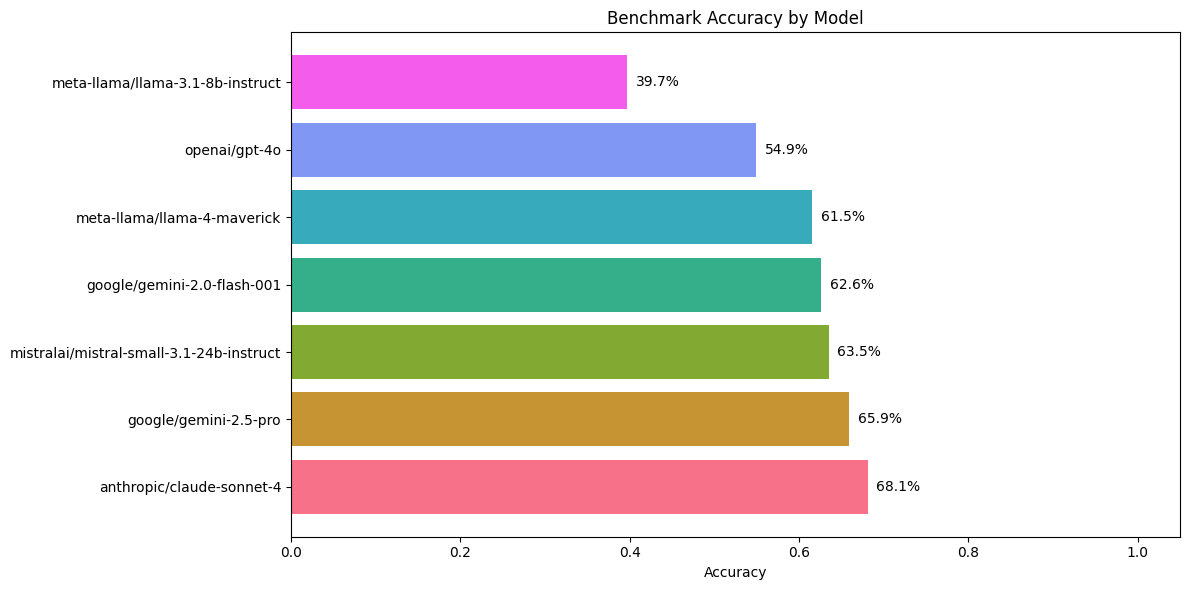

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("husl", len(summary))
bars = ax.barh(summary["model"], summary["accuracy"], color=colors)
ax.set_xlabel("Accuracy")
ax.set_title("Benchmark Accuracy by Model")
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, summary["accuracy"]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va="center",
    )
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "accuracy_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## Accuracy by Model and Question Type (Text vs Visual)

In [5]:
type_pivot = (
    df.groupby(["model", "question_type"])
    .agg(
        total=("is_correct", "count"),
        correct=("is_correct", "sum"),
        accuracy=("is_correct", "mean"),
    )
    .reset_index()
    .pivot_table(index="model", columns="question_type", values="accuracy")
)
type_pivot.style.format("{:.1%}")

question_type,text_only,visual
model,,
anthropic/claude-sonnet-4,79.4%,42.9%
google/gemini-2.0-flash-001,73.0%,39.3%
google/gemini-2.5-pro,71.4%,53.6%
meta-llama/llama-3.1-8b-instruct,39.7%,nan%
meta-llama/llama-4-maverick,68.3%,46.4%
mistralai/mistral-small-3.1-24b-instruct,63.5%,nan%
openai/gpt-4o,61.9%,39.3%


In [6]:
melted = type_pivot.reset_index().melt(
    id_vars="model", var_name="question_type", value_name="accuracy"
)
fig = px.bar(
    melted,
    x="model",
    y="accuracy",
    color="question_type",
    barmode="group",
    title="Text-Only vs Visual Question Accuracy by Model",
    labels={"accuracy": "Accuracy", "model": "Model"},
)
fig.update_layout(yaxis_range=[0, 1])
fig.write_html(str(OUTPUT_DIR / "text_vs_visual.html"))
try:
    fig.write_image(str(OUTPUT_DIR / "text_vs_visual.png"))
except Exception:
    pass
fig.show()

## Accuracy Heatmap by Model and Chapter

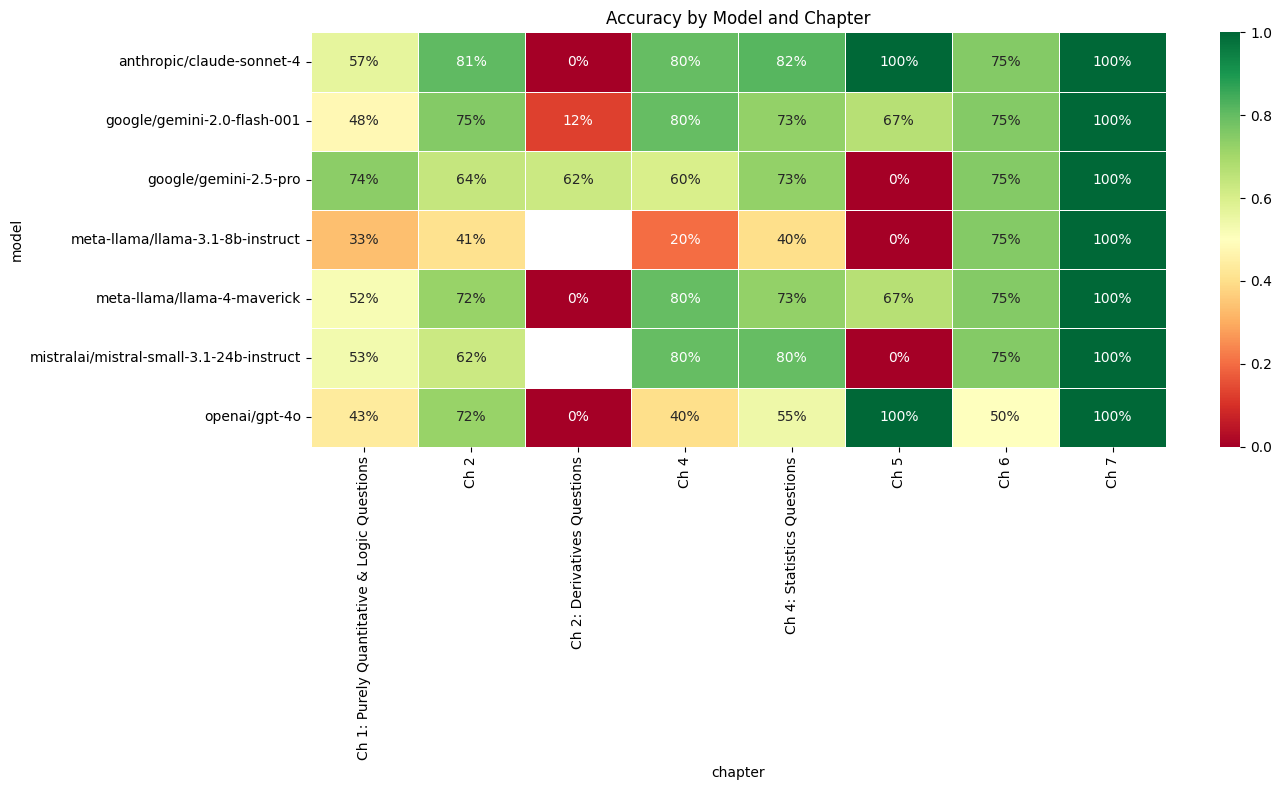

In [7]:
chapter_pivot = (
    df.groupby(["model", "chapter"])
    .agg(accuracy=("is_correct", "mean"), count=("is_correct", "count"))
    .reset_index()
    .pivot_table(index="model", columns="chapter", values="accuracy")
)
if not chapter_pivot.empty:
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        chapter_pivot,
        annot=True,
        fmt=".0%",
        cmap="RdYlGn",
        ax=ax,
        vmin=0,
        vmax=1,
        linewidths=0.5,
    )
    ax.set_title("Accuracy by Model and Chapter")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "accuracy_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

## Accuracy by Difficulty

In [8]:
df_d = df[df["difficulty"].notna() & (df["difficulty"] != "") & (df["difficulty"] != "nan")]
if not df_d.empty:
    diff_pivot = (
        df_d.groupby(["model", "difficulty"])
        .agg(accuracy=("is_correct", "mean"), count=("is_correct", "count"))
        .reset_index()
        .pivot_table(index="model", columns="difficulty", values="accuracy")
    )
    diff_pivot.style.format("{:.1%}")
else:
    print("No difficulty data available.")

## Accuracy by Source Book

In [9]:
book_pivot = (
    df.groupby(["model", "source_book"])
    .agg(accuracy=("is_correct", "mean"), count=("is_correct", "count"))
    .reset_index()
    .pivot_table(index="model", columns="source_book", values="accuracy")
)
book_pivot.style.format("{:.1%}")

source_book,green_book,heard_on_the_street
model,,
anthropic/claude-sonnet-4,81.6%,52.4%
google/gemini-2.0-flash-001,75.5%,47.6%
google/gemini-2.5-pro,61.2%,71.4%
meta-llama/llama-3.1-8b-instruct,41.9%,35.0%
meta-llama/llama-4-maverick,73.5%,47.6%
mistralai/mistral-small-3.1-24b-instruct,65.1%,60.0%
openai/gpt-4o,69.4%,38.1%


## Response Latency by Model

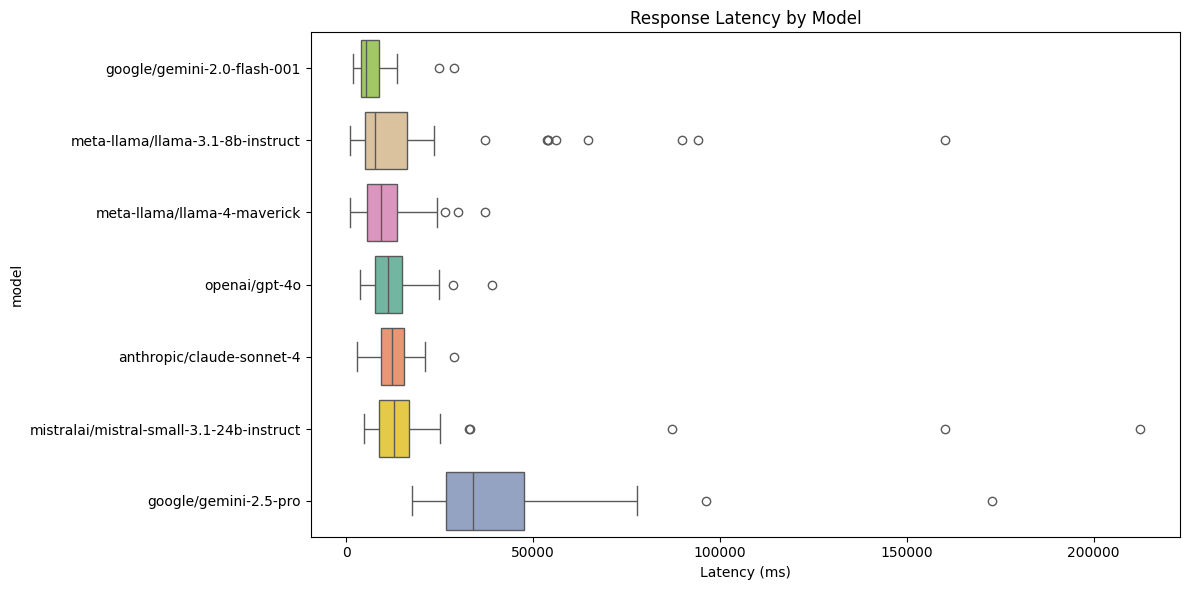

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
models_sorted = (
    df.groupby("model")["latency_ms"].median().sort_values().index.tolist()
)
sns.boxplot(
    data=df,
    y="model",
    x="latency_ms",
    hue="model",
    order=models_sorted,
    ax=ax,
    palette="Set2",
    legend=False,
)
ax.set_xlabel("Latency (ms)")
ax.set_title("Response Latency by Model")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "latency_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## Cost-Efficiency: Accuracy vs Token Usage

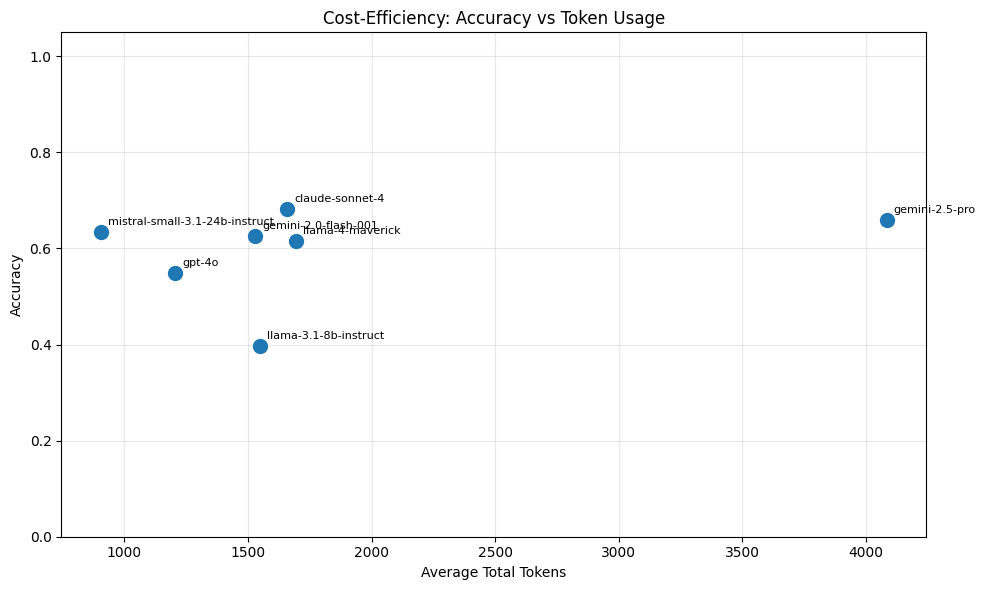

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary["avg_tokens"], summary["accuracy"], s=100, zorder=5)
for _, row in summary.iterrows():
    ax.annotate(
        row["model"].split("/")[-1],
        (row["avg_tokens"], row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )
ax.set_xlabel("Average Total Tokens")
ax.set_ylabel("Accuracy")
ax.set_title("Cost-Efficiency: Accuracy vs Token Usage")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Examples of Correct and Incorrect Answers

For a selection of models, we show one question that was answered correctly
and one that was answered incorrectly, along with the model's extracted answer,
the reference answer, and the grader's explanation.

In [12]:
# Pick a subset of models to keep the output readable
example_models = df["model"].unique()[:3]

for model_name in example_models:
    model_df = df[df["model"] == model_name]
    correct = model_df[model_df["is_correct"]].head(1)
    incorrect = model_df[~model_df["is_correct"]].head(1)

    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print("=" * 70)

    if not correct.empty:
        r = correct.iloc[0]
        print(f"\n  CORRECT example: {r['title']} ({r['question_id']})")
        print(f"    Extracted answer : {str(r['extracted_answer'])[:300]}")
        print(f"    Reference answer : {str(r['reference_answer'])[:300]}")
        print(f"    Grader           : {r['grader_explanation']}")

    if not incorrect.empty:
        r = incorrect.iloc[0]
        print(f"\n  INCORRECT example: {r['title']} ({r['question_id']})")
        print(f"    Extracted answer : {str(r['extracted_answer'])[:300]}")
        print(f"    Reference answer : {str(r['reference_answer'])[:300]}")
        print(f"    Grader           : {r['grader_explanation']}")


Model: openai/gpt-4o

  CORRECT example: Calendar cubes (text_only_q010)
    Extracted answer : Die 1: 0, 1, 2, 3, 4, 5; Die 2: 0, 1, 2, 6, 7, 8 (9 is represented by flipping 6)
    Reference answer : Dice 1: 0,1,2,3,4,5; Dice 2: 0,1,2,6,7,8 (use 6 upside down as 9)
    Grader           : The candidate's answer is mathematically equivalent to the reference answer.

  INCORRECT example: HOTS Q2.12 (visual_q018)
    Extracted answer : The delta of a down-and-out call is generally lower than a standard call, especially near the barrier.
    Reference answer : Power option pricing: uses adjusted Black-Scholes with power parameter a; delta approaches a*S^(a-1) deep ITM
    Grader           : The candidate's answer discusses down-and-out call options, which are unrelated to the reference answer's focus on power options and their delta.

Model: anthropic/claude-sonnet-4

  CORRECT example: Calendar cubes (text_only_q010)
    Extracted answer : Die A: {0, 1, 2, 4, 5, 6}, Die B: {1, 2, 3, 7, 8

## Easiest and Hardest Questions by Type

We compute per-question accuracy (fraction of models that got the question
right) and show the top-5 easiest and top-5 hardest for each question type.

In [13]:
question_acc = (
    df.groupby(["question_id", "question_type", "title"])
    .agg(
        models_correct=("is_correct", "sum"),
        models_total=("is_correct", "count"),
        accuracy=("is_correct", "mean"),
    )
    .reset_index()
    .sort_values("accuracy")
)

for qtype in ["text_only", "visual"]:
    subset = question_acc[question_acc["question_type"] == qtype]
    if subset.empty:
        continue

    easiest = subset.nlargest(5, "accuracy")
    hardest = subset.nsmallest(5, "accuracy")

    print(f"\n{'='*70}")
    print(f"Question type: {qtype}")
    print("=" * 70)
    print(f"\n  Top 5 EASIEST (highest accuracy across models):")
    for _, r in easiest.iterrows():
        print(
            f"    {r['accuracy']:.0%} ({r['models_correct']:.0f}/{r['models_total']:.0f}) "
            f"- {r['title']} [{r['question_id']}]"
        )
    print(f"\n  Top 5 HARDEST (lowest accuracy across models):")
    for _, r in hardest.iterrows():
        print(
            f"    {r['accuracy']:.0%} ({r['models_correct']:.0f}/{r['models_total']:.0f}) "
            f"- {r['title']} [{r['question_id']}]"
        )


Question type: text_only

  Top 5 EASIEST (highest accuracy across models):
    100% (7/7) - HOTS Q1.3 [text_only_q046]
    100% (7/7) - River crossing [text_only_q003]
    100% (7/7) - Burning ropes [text_only_q006]
    100% (7/7) - Trailing zeros [text_only_q007]
    100% (7/7) - Infinite sequence [text_only_q009]

  Top 5 HARDEST (lowest accuracy across models):
    0% (0/7) - HOTS Q1.9 [text_only_q051]
    0% (0/7) - Rainbow hats [text_only_q032]
    0% (0/7) - Ants on a square [text_only_q025]
    14% (1/7) - Screwy pirates [text_only_q001]
    14% (1/7) - HOTS Q1.10 [text_only_q052]

Question type: visual

  Top 5 EASIEST (highest accuracy across models):
    100% (5/5) - Race track [visual_q004]
    100% (5/5) - HOTS Q1.27 [visual_q008]
    100% (5/5) - HOTS Q4.37 [visual_q027]
    100% (5/5) - Defective ball [visual_q001]
    100% (5/5) - Box packing [visual_q002]

  Top 5 HARDEST (lowest accuracy across models):
    0% (0/5) - HOTS Q1.52 [visual_q013]
    0% (0/5) - HOTS Q1.5

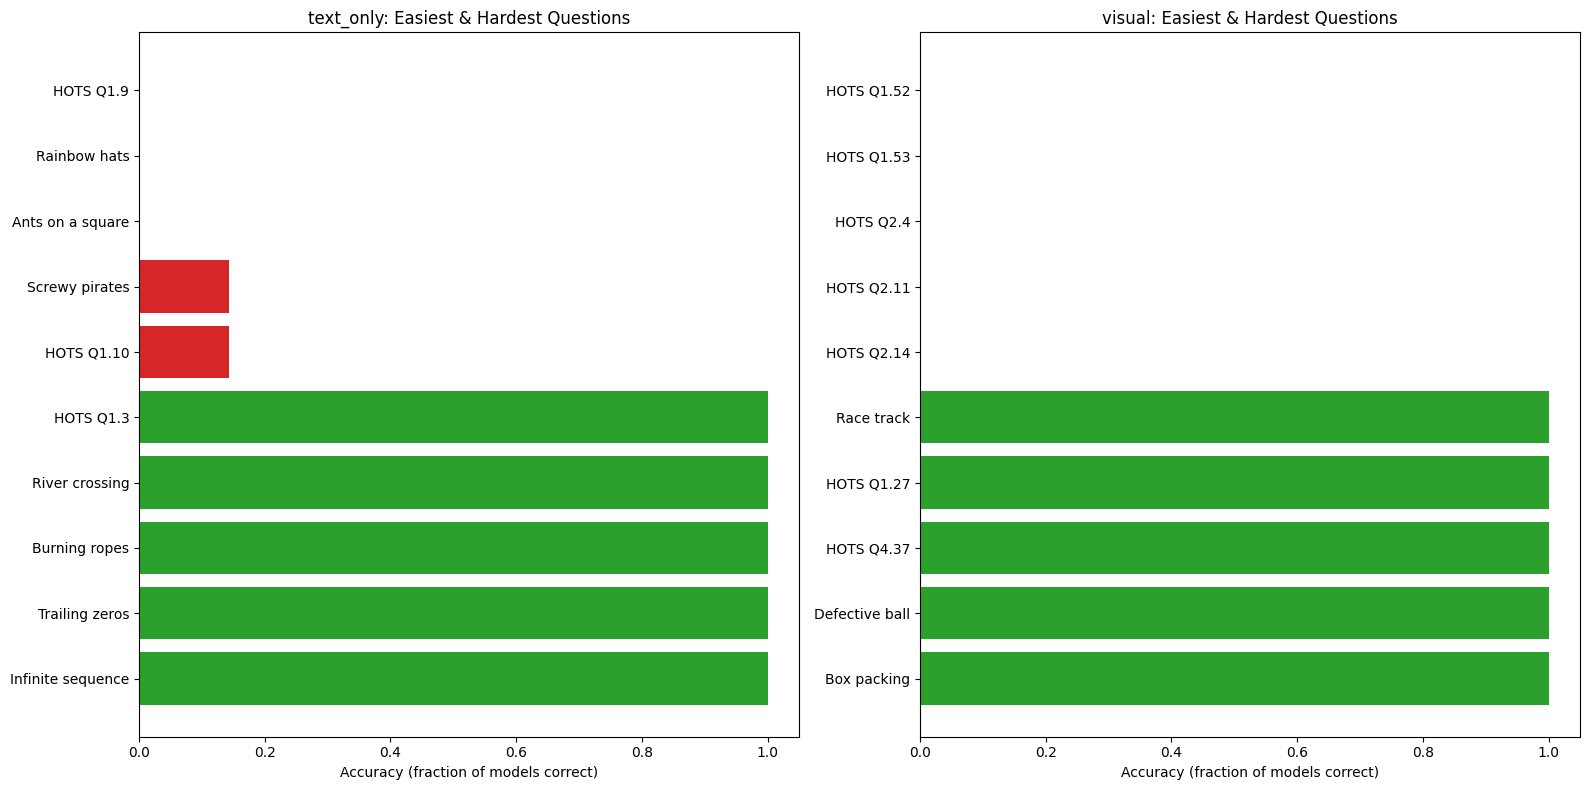

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)
for idx, qtype in enumerate(["text_only", "visual"]):
    subset = question_acc[question_acc["question_type"] == qtype]
    if subset.empty:
        continue

    # Combine easiest and hardest
    easiest = subset.nlargest(5, "accuracy").assign(category="Easiest")
    hardest = subset.nsmallest(5, "accuracy").assign(category="Hardest")
    combined = pd.concat([hardest, easiest]).reset_index(drop=True)

    ax = axes[idx]
    colors = ["#d62728" if c == "Hardest" else "#2ca02c" for c in combined["category"]]
    ax.barh(combined["title"], combined["accuracy"], color=colors)
    ax.set_xlabel("Accuracy (fraction of models correct)")
    ax.set_title(f"{qtype}: Easiest & Hardest Questions")
    ax.set_xlim(0, 1.05)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "easiest_hardest_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Error Summary

In [15]:
errors = df[df["error"].notna() & (df["error"] != "")]
if not errors.empty:
    print(f"Total errors: {len(errors)} failed requests")
    errors[["question_id", "model", "error"]].head(20)
else:
    print("No errors recorded.")

No errors recorded.
